In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

In [ ]:
IMG_SIZE = 256
CLASSES = ["normal", "benign", "malignant"]
checkpoint_path = "/content/drive/MyDrive/Breast_cancer/best_inceptionresnetv2_multi_task.keras"

In [ ]:
# Folder to save Grad-CAM results
save_dir = "/content/drive/MyDrive/Breast_cancer/GradCAM_results"
os.makedirs(save_dir, exist_ok=True)

In [ ]:
model = tf.keras.models.load_model(checkpoint_path, compile=False)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_211 (Conv2D) │ (None, 127, 127,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 127, 127,  │         96 │ conv2d_211[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_203      │ (None, 127, 127,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_212 (Conv2D) │ (None, 125, 125,  │      9,216 │ activation_203[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 125,  │         96 │ conv2d_212[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_204      │ (None, 125, 125,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_213 (Conv2D) │ (None, 125, 125,  │     18,432 │ activation_204[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 125,  │        192 │ conv2d_213[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_205      │ (None, 125, 125,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 62, 62,    │          0 │ activation_205[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_214 (Conv2D) │ (None, 62, 62,    │      5,120 │ max_pooling2d_4[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 62, 62,    │        240 │ conv2d_214[0][0]  │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_206      │ (None, 62, 62,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_215 (Conv2D) │ (None, 60, 60,    │    138,240 │ activation_206[0… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 60,    │        576 │ conv2d_215[0][0]  │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_207      │ (None, 60, 60,    │          0 │ batch_normalizat

 Total params: 66,963,428 (255.45 MB)

 Trainable params: 66,902,884 (255.21 MB)

 Non-trainable params: 60,544 (236.50 KB)

In [ ]:
# ================== Preprocessing ==================
from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input as irv2_preprocess

def preprocess_img(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = irv2_preprocess(img)
    img = tf.expand_dims(img, axis=0)
    return img

In [ ]:

# ================== Grad-CAM Function ==================
def grad_cam(model, img_tensor, class_idx=None, layer_name='conv_7b_ac'):
    last_conv_layer = model.get_layer(layer_name)
    grad_model = tf.keras.models.Model([model.inputs],
                                       [last_conv_layer.output, model.get_layer("classification_output").output])

    with tf.GradientTape() as tape:
        # Nested list to match input structure and remove warning
        conv_outputs, predictions = grad_model([[img_tensor]])
        if class_idx is None:
            class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    weights = tf.reduce_mean(grads, axis=(1,2))
    cam = tf.reduce_sum(tf.multiply(weights[:, tf.newaxis, tf.newaxis, :], conv_outputs), axis=-1)
    cam = tf.nn.relu(cam)
    cam = cam[0].numpy()
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam


In [ ]:
# ================== Overlay Function ==================
def overlay_cam(img_path, cam, alpha=0.4, colormap=cv2.COLORMAP_JET):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    heatmap = cv2.applyColorMap(np.uint8(255*cam), colormap)
    overlay = cv2.addWeighted(img, 1-alpha, heatmap, alpha, 0)
    return overlay
    import matplotlib.pyplot as plt

def visualize_gradcam(img_path, cam, actual_class, pred_class, alpha=0.4):
    # Load original image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(cv2.resize(img, (IMG_SIZE, IMG_SIZE)), cv2.COLOR_BGR2RGB)

    # Grad-CAM heatmap
    heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Overlay
    overlay = cv2.addWeighted(img, 1-alpha, heatmap, alpha, 0)

    # Plot side by side
    fig, axes = plt.subplots(1, 3, figsize=(18,6))
    axes[0].imshow(img)
    axes[0].axis('off')
    axes[0].set_title("Original Image")

    axes[1].imshow(heatmap)
    axes[1].axis('off')
    axes[1].set_title("Grad-CAM Heatmap")

    axes[2].imshow(overlay)
    axes[2].axis('off')
    axes[2].set_title(f"Overlay\nActual: {actual_class} | Pred: {pred_class}")

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


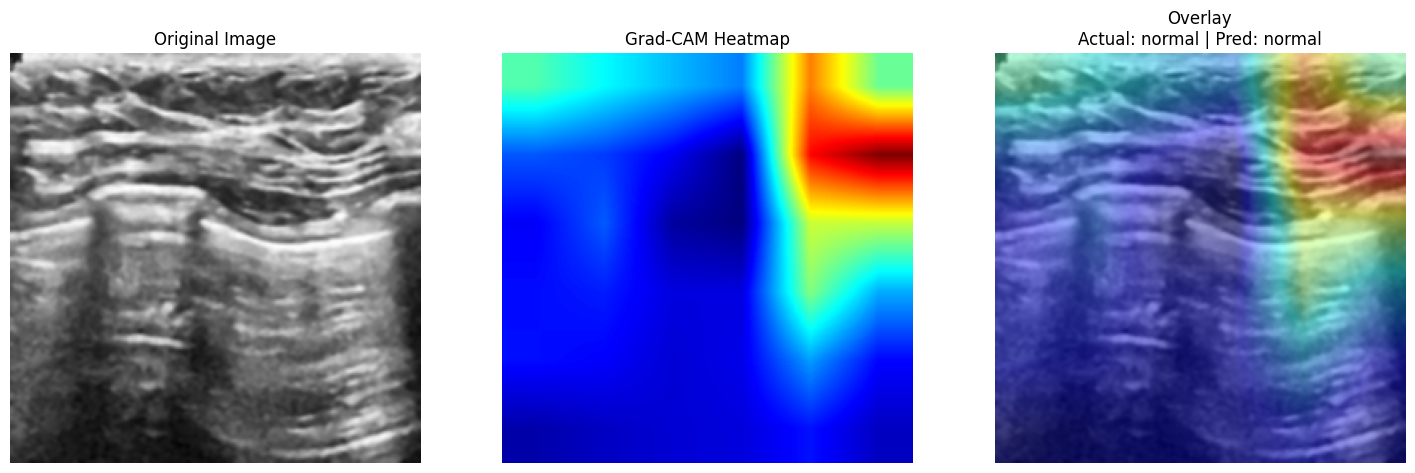

Saved Grad-CAM overlay to: /content/drive/MyDrive/Breast_cancer/GradCAM_results/normal (108)_gradcam.png



In [ ]:
# Single image
test_image_paths = ["/content/drive/MyDrive/Breast_cancer/Processed/test/normal/images/normal (108).png"]

for img_path in test_image_paths:
    img_tensor = preprocess_img(img_path)

    # Extract actual class from folder name
    actual_class = os.path.basename(os.path.dirname(os.path.dirname(img_path)))

    # Predict class
    preds = model.predict([[img_tensor]])  # nested list to remove warning
    pred_class = CLASSES[np.argmax(preds[1][0])]

    # Grad-CAM
    cam = grad_cam(model, img_tensor, class_idx=np.argmax(preds[1][0]), layer_name='conv_7b_ac')

    # Visualize original, heatmap, overlay with text
    visualize_gradcam(img_path, cam, actual_class, pred_class)

    # Optional: save overlay
    overlay_img = overlay_cam(img_path, cam)
    save_path = os.path.join(save_dir, f"{os.path.basename(img_path).split('.')[0]}_gradcam.png")
    cv2.imwrite(save_path, overlay_img)
    print(f"Saved Grad-CAM overlay to: {save_path}\n")


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# ================== Setup ==================
IMG_SIZE = 256
CLASSES = ["normal", "benign", "malignant"]
checkpoint_path = "/content/drive/MyDrive/Breast_cancer/best_inceptionresnetv2_multi_task.keras"
test_dir = "/content/drive/MyDrive/Breast_cancer/Processed/test"
save_dir = "/content/drive/MyDrive/Breast_cancer/Explainability_outputs"
os.makedirs(save_dir, exist_ok=True)

model = tf.keras.models.load_model(checkpoint_path, compile=False)

# ================== Preprocessing ==================
from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input as irv2_preprocess

def preprocess_img(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = irv2_preprocess(img)
    img = tf.expand_dims(img, axis=0)
    return img

# ================== Grad-CAM ==================
def grad_cam(model, img_tensor, class_idx=None, layer_name='conv_7b_ac'):
    last_conv_layer = model.get_layer(layer_name)
    grad_model = tf.keras.models.Model([model.inputs],
                                       [last_conv_layer.output, model.get_layer("classification_output").output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model([[img_tensor]])
        if class_idx is None:
            class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    weights = tf.reduce_mean(grads, axis=(1,2))
    cam = tf.reduce_sum(tf.multiply(weights[:, tf.newaxis, tf.newaxis, :], conv_outputs), axis=-1)
    cam = tf.nn.relu(cam)[0].numpy()
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam

# ================== Guided Grad-CAM ==================
@tf.custom_gradient
def guided_relu(x):
    def grad(dy):
        return dy * tf.cast(dy > 0, tf.float32) * tf.cast(x > 0, tf.float32)
    return tf.nn.relu(x), grad

def replace_relu_with_guided(model):
    guided_model = tf.keras.models.clone_model(
        model,
        clone_function=lambda layer: layer.__class__.from_config(layer.get_config())
        if not hasattr(layer, 'activation') else
        tf.keras.layers.Activation(lambda x: guided_relu(x)) if layer.activation == tf.nn.relu else layer
    )
    guided_model.set_weights(model.get_weights())
    return guided_model

def guided_grad_cam(model, img_tensor, class_idx=None, layer_name='conv_7b_ac'):
    # Grad-CAM
    last_conv_layer = model.get_layer(layer_name)
    grad_model = tf.keras.models.Model([model.inputs],
                                       [last_conv_layer.output, model.get_layer("classification_output").output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model([[img_tensor]])
        if class_idx is None:
            class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    weights = tf.reduce_mean(grads, axis=(1,2))
    cam = tf.reduce_sum(tf.multiply(weights[:, tf.newaxis, tf.newaxis, :], conv_outputs), axis=-1)
    cam = tf.nn.relu(cam)[0].numpy()
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    # Guided Backprop
    guided_model = replace_relu_with_guided(model)
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        preds = guided_model([[img_tensor]])
        if class_idx is None:
            class_idx = tf.argmax(preds[0])
        loss = preds[1][:, class_idx]

    guided_grads = tape.gradient(loss, img_tensor)[0].numpy()
    guided_grads = guided_grads * cam[..., np.newaxis]
    guided_grads = (guided_grads - guided_grads.min()) / (guided_grads.max() - guided_grads.min() + 1e-8)
    return guided_grads

# ================== Save Functions ==================
def save_image(img_array, save_path):
    if img_array.ndim == 3 and img_array.shape[2] == 3:
        img_array = (img_array * 255).astype(np.uint8)
    else:
        img_array = (img_array * 255).astype(np.uint8)
        img_array = cv2.applyColorMap(img_array, cv2.COLORMAP_JET)
    cv2.imwrite(save_path, img_array)
    print(f"Saved: {save_path}")

def create_side_by_side(original, gradcam, guided_gradcam, save_path):
    original = cv2.resize(original, (IMG_SIZE, IMG_SIZE))
    gradcam = cv2.resize(gradcam, (IMG_SIZE, IMG_SIZE))
    guided_gradcam = cv2.resize(guided_gradcam, (IMG_SIZE, IMG_SIZE))

    # Convert to 3-channel BGR if needed
    if gradcam.ndim == 2: gradcam = cv2.applyColorMap((gradcam*255).astype(np.uint8), cv2.COLORMAP_JET)
    if guided_gradcam.ndim == 2: guided_gradcam = cv2.applyColorMap((guided_gradcam*255).astype(np.uint8), cv2.COLORMAP_JET)

    combined = np.concatenate([original, gradcam, guided_gradcam], axis=1)
    cv2.imwrite(save_path, combined)
    print(f"Saved side-by-side: {save_path}")

# ================== Main Loop ==================
for root, _, files in os.walk(test_dir):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            img_path = os.path.join(root, file)
            img_tensor = preprocess_img(img_path)
            original_img = cv2.imread(img_path)
            original_img = cv2.resize(original_img, (IMG_SIZE, IMG_SIZE))

            preds = model.predict([[img_tensor]])
            pred_class_idx = np.argmax(preds[1][0])
            pred_class = CLASSES[pred_class_idx]

            # Grad-CAM
            cam = grad_cam(model, img_tensor, class_idx=pred_class_idx)
            save_image(cam, os.path.join(save_dir, f"{file.split('.')[0]}_gradcam.png"))

            # Guided Grad-CAM
            guided_cam = guided_grad_cam(model, img_tensor, class_idx=pred_class_idx)
            save_image(guided_cam, os.path.join(save_dir, f"{file.split('.')[0]}_guided_gradcam.png"))

            # Side-by-side comparison
            create_side_by_side(original_img, cam, guided_cam,
                                os.path.join(save_dir, f"{file.split('.')[0]}_comparison.png"))


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Saved: /content/drive/MyDrive/Breast_cancer/Explainability_outputs/normal (35)_gradcam.png


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=[['Tensor(shape=(1, 256, 256, 3))']]
  warnings.warn(msg)


Saved: /content/drive/MyDrive/Breast_cancer/Explainability_outputs/normal (35)_guided_gradcam.png
Saved side-by-side: /content/drive/MyDrive/Breast_cancer/Explainability_outputs/normal (35)_comparison.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 832ms/step
Saved: /content/drive/MyDrive/Breast_cancer/Explainability_outputs/normal (108)_gradcam.png
Saved: /content/drive/MyDrive/Breast_cancer/Explainability_outputs/normal (108)_guided_gradcam.png
Saved side-by-side: /content/drive/MyDrive/Breast_cancer/Explainability_outputs/normal (108)_comparison.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 773ms/step
Saved: /content/drive/MyDrive/Breast_cancer/Explainability_outputs/normal (65)_gradcam.png
Saved: /content/drive/MyDrive/Breast_cancer/Explainability_outputs/normal (65)_guided_gradcam.png
Saved side-by-side: /content/drive/MyDrive/Breast_cancer/Explainability_outputs/normal (65)_comparison.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 798ms/step
Saved: /content/drive/MyDrive/Breast_cancer/Explainability_outputs/normal (33)_grad

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# ================== Setup ==================
IMG_SIZE = 256
CLASSES = ["normal", "benign", "malignant"]
checkpoint_path = "/content/drive/MyDrive/Breast_cancer/best_inceptionresnetv2_multi_task.keras"
test_dir = "/content/drive/MyDrive/Breast_cancer/Processed/test"
save_dir = "/content/drive/MyDrive/Breast_cancer/Explainability_outputs2"
os.makedirs(save_dir, exist_ok=True)

model = tf.keras.models.load_model(checkpoint_path, compile=False)

# ================== Preprocessing ==================
from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input as irv2_preprocess

def preprocess_img(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = irv2_preprocess(img)
    img = tf.expand_dims(img, axis=0)
    return img

# ================== Grad-CAM ==================
def grad_cam(model, img_tensor, class_idx=None, layer_name='conv_7b_ac'):
    last_conv_layer = model.get_layer(layer_name)
    grad_model = tf.keras.models.Model([model.inputs],
                                       [last_conv_layer.output, model.get_layer("classification_output").output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model([[img_tensor]])
        if class_idx is None:
            class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    weights = tf.reduce_mean(grads, axis=(1,2))
    cam = tf.reduce_sum(tf.multiply(weights[:, tf.newaxis, tf.newaxis, :], conv_outputs), axis=-1)
    cam = tf.nn.relu(cam)[0].numpy()
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam

# ================== Guided Grad-CAM ==================
@tf.custom_gradient
def guided_relu(x):
    def grad(dy):
        return dy * tf.cast(dy > 0, tf.float32) * tf.cast(x > 0, tf.float32)
    return tf.nn.relu(x), grad

def replace_relu_with_guided(model):
    guided_model = tf.keras.models.clone_model(
        model,
        clone_function=lambda layer: layer.__class__.from_config(layer.get_config())
        if not hasattr(layer, 'activation') else
        tf.keras.layers.Activation(lambda x: guided_relu(x)) if layer.activation == tf.nn.relu else layer
    )
    guided_model.set_weights(model.get_weights())
    return guided_model

def guided_grad_cam(model, img_tensor, class_idx=None, layer_name='conv_7b_ac'):
    # Grad-CAM
    last_conv_layer = model.get_layer(layer_name)
    grad_model = tf.keras.models.Model([model.inputs],
                                       [last_conv_layer.output, model.get_layer("classification_output").output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model([[img_tensor]])
        if class_idx is None:
            class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    weights = tf.reduce_mean(grads, axis=(1,2))
    cam = tf.reduce_sum(tf.multiply(weights[:, tf.newaxis, tf.newaxis, :], conv_outputs), axis=-1)
    cam = tf.nn.relu(cam)[0].numpy()
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    # Guided Backprop
    guided_model = replace_relu_with_guided(model)
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        preds = guided_model([[img_tensor]])
        if class_idx is None:
            class_idx = tf.argmax(preds[0])
        loss = preds[1][:, class_idx]

    guided_grads = tape.gradient(loss, img_tensor)[0].numpy()
    guided_grads = guided_grads * cam[..., np.newaxis]
    guided_grads = (guided_grads - guided_grads.min()) / (guided_grads.max() - guided_grads.min() + 1e-8)
    return guided_grads

# ================== Integrated Gradients ==================
def integrated_gradients(model, img_tensor, class_idx=None, m_steps=50, baseline=None):
    if baseline is None:
        baseline = tf.zeros_like(img_tensor)
    img_tensor = tf.cast(img_tensor, tf.float32)
    baseline = tf.cast(baseline, tf.float32)
    scaled_inputs = [baseline + (float(i)/m_steps)*(img_tensor - baseline) for i in range(m_steps+1)]
    grads = []
    for scaled_input in scaled_inputs:
        with tf.GradientTape() as tape:
            tape.watch(scaled_input)
            pred = model([[scaled_input]])[1]
            if class_idx is None:
                class_idx = tf.argmax(pred[0])
            loss = pred[:, class_idx]
        grad = tape.gradient(loss, scaled_input)[0].numpy()
        grads.append(grad)
    avg_grads = np.mean(np.array(grads[:-1]), axis=0)
    integrated_grad = (img_tensor[0].numpy() - baseline[0].numpy()) * avg_grads
    integrated_grad = (integrated_grad - integrated_grad.min()) / (integrated_grad.max() - integrated_grad.min() + 1e-8)
    return integrated_grad

# ================== Save Functions ==================
def save_overlay(img_array, original_img, save_path, alpha=0.4):
    original_img = cv2.resize(original_img, (IMG_SIZE, IMG_SIZE))
    overlay = (img_array*255).astype(np.uint8)
    if overlay.ndim == 3 and overlay.shape[2]==3:
        overlay_bgr = cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
    else:
        overlay_bgr = cv2.applyColorMap(overlay, cv2.COLORMAP_JET)
    combined = cv2.addWeighted(original_img, 1-alpha, overlay_bgr, alpha, 0)
    cv2.imwrite(save_path, combined)
    print(f"Saved: {save_path}")

def save_comparison(original, gradcam, guided, ig, save_path):
    original = cv2.resize(original, (IMG_SIZE, IMG_SIZE))
    def to_bgr(img):
        if img.ndim==2: return cv2.applyColorMap((img*255).astype(np.uint8), cv2.COLORMAP_JET)
        return cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
    gradcam_bgr = to_bgr(gradcam)
    guided_bgr = to_bgr(guided)
    ig_bgr = to_bgr(ig)
    combined = np.concatenate([original, gradcam_bgr, guided_bgr, ig_bgr], axis=1)
    cv2.imwrite(save_path, combined)
    print(f"Saved side-by-side comparison: {save_path}")

# ================== Main Loop ==================
for root, _, files in os.walk(test_dir):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            img_path = os.path.join(root, file)
            img_tensor = preprocess_img(img_path)
            original_img = cv2.imread(img_path)
            original_img = cv2.resize(original_img, (IMG_SIZE, IMG_SIZE))

            preds = model.predict([[img_tensor]])
            pred_class_idx = np.argmax(preds[1][0])
            pred_class = CLASSES[pred_class_idx]
            pred_prob = preds[1][0][pred_class_idx]

            # Grad-CAM
            cam = grad_cam(model, img_tensor, class_idx=pred_class_idx)
            save_overlay(cam, original_img, os.path.join(save_dir, f"{file.split('.')[0]}_gradcam.png"))

            # Guided Grad-CAM
            guided_cam = guided_grad_cam(model, img_tensor, class_idx=pred_class_idx)
            save_overlay(guided_cam, original_img, os.path.join(save_dir, f"{file.split('.')[0]}_guided_gradcam.png"))

            # Integrated Gradients
            ig = integrated_gradients(model, img_tensor, class_idx=pred_class_idx)
            save_overlay(ig, original_img, os.path.join(save_dir, f"{file.split('.')[0]}_integratedgrad.png"))

            # Side-by-side
            save_comparison(original_img, cam, guided_cam, ig,
                            os.path.join(save_dir, f"{file.split('.')[0]}_comparison.png"))


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=(('Tensor(shape=(1, 256, 256, 3))',),)
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Saved: /content/drive/MyDrive/Breast_cancer/Explainability_outputs2/normal (35)_gradcam.png


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=[['Tensor(shape=(1, 256, 256, 3))']]
  warnings.warn(msg)


Saved: /content/drive/MyDrive/Breast_cancer/Explainability_outputs2/normal (35)_guided_gradcam.png
Saved: /content/drive/MyDrive/Breast_cancer/Explainability_outputs2/normal (35)_integratedgrad.png
Saved side-by-side comparison: /content/drive/MyDrive/Breast_cancer/Explainability_outputs2/normal (35)_comparison.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step
Saved: /content/drive/MyDrive/Breast_cancer/Explainability_outputs2/normal (108)_gradcam.png
Saved: /content/drive/MyDrive/Breast_cancer/Explainability_outputs2/normal (108)_guided_gradcam.png
Saved: /content/drive/MyDrive/Breast_cancer/Explainability_outputs2/normal (108)_integratedgrad.png
Saved side-by-side comparison: /content/drive/MyDrive/Breast_cancer/Explainability_outputs2/normal (108)_comparison.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step
Saved: /content/drive/MyDrive/Breast_cancer/Explainability_outputs2/normal (65)_gradcam.png
Saved: /content/drive/MyDrive/Breast_cancer/Explainability_outputs2/normal (65)_guided_gradcam.png
S